# Market Risk Project 2025-2026

**Authors:** Matthieu HANNA GERGUIS & Renaud DE L'EPINE  
**Class:** A4-IF3  
**Professor:** Nicolas PESCI  

---

### Project Overview
This notebook contains the complete work for the *Market Risk Project (2025-2026)* and will be complemented by a final written report. It includes the implementation of the methods studied in class and the the interpretation of numerical results.

Throughout this project we chose to use **Git and GitHub**. This allowed us to save our progress and track changes over time to keep the project well-organized. This will be useful to present our work and adopt good working habits.

The GitHub repository for this project is available at: https://github.com/MatthieuHannaGerguis/MarketRisk_Project_Hanna_Gerguis_DeLEpine

### Reading Guide - Code Colour Convention Used in This Notebook

To facilitate reading we use a **code colour convention** in the notebook.  
This allows to immediately distinguish between course elements and practical or methodological remarks.

The following colour code is used consistently:

> <span style="color:#1f4fd8"><strong>Theory</strong></span>  
> <span style="color:#1f4fd8">Course content, definitions, formulas and reminders.</span>

> <span style="color:#0b7a3e"><strong>Analysis</strong></span>  
> <span style="color:#0b7a3e">Interpretation of results and discussion</span>

> <span style="color:#7a3e0b"><strong>Remark</strong></span>  
> <span style="color:#7a3e0b">Practical notes/ assumptions and methodological choices.</span>

### Project Structure
The project is organized question by question following the project instructions. 
A consistent structure is used in our notebook to separate theory, code, results and analysis.

We now start with Question A.

---


### Question A (Ex2, part of Q1 and Q2 of TD1) - Historical VaR (Non-parametric)

The objective of this question is to estimate the market risk of the Natixis stock using a historical, non-parametric approach(VaR).

<span style="color:#0b7a3e"> All VaR estimates in this section are at the 5% confidence level</span>

#### I. Data preparation and return computation

We start by loading the Natixis price data (between January 2015 and December 2016) provided for the project and computing daily returns from prices just after transforming the date and chronological ordering.

<span style="color:#7a3e0b"><strong>Remark:</strong> The same dataset "Natixis_stock" and return series will be used in Questions B and. Thus, the data preparation is done once andoesn'tpchanges.</span>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#data = pd.read_csv("../data/Natixis_stock.txt", delimiter='\t', 
                   #header=None, parse_dates=[0]) #we will mainly use main dataframe to analyze data in our whole project
data = pd.read_csv("../data/Natixis_stock.txt", delimiter='\t', 
                   header=None, parse_dates=[0])
data.columns = ['Date', 'Value'] # rename columns
data['Date'] = pd.to_datetime(data['Date'], format="%d/%m/%Y") 

data['Value'] = data['Value'].str.replace(',', '.').astype(float) #retype float number as we read a txt
data = data.sort_values('Date') # let's sort by date to calculate returns 

def Returns(data): #function to go to the next row in the same column(we didn't use pct_change() a pandas functiob)
    data['Returns'] = (data['Value'] - data['Value'].shift(1)) / data['Value'].shift(1)
    return data

data = Returns(data)
print(data)

#the first value of returns is NaN which is logical so we decided to erase the row from our dataset
data = data.dropna()
print(data)


alpha = 0.05 #probability level targeted  
value_portfolio = 100000 #value portfolio is the actual value of the portfolio

           Date  Value   Returns
0    2015-01-02  5.621       NaN
1    2015-01-05  5.424 -0.035047
2    2015-01-06  5.329 -0.017515
3    2015-01-07  5.224 -0.019704
4    2015-01-08  5.453  0.043836
...         ...    ...       ...
1018 2018-12-21  4.045 -0.001481
1019 2018-12-24  4.010 -0.008653
1020 2018-12-27  3.938 -0.017955
1021 2018-12-28  4.088  0.038090
1022 2018-12-31  4.119  0.007583

[1023 rows x 3 columns]
           Date  Value   Returns
1    2015-01-05  5.424 -0.035047
2    2015-01-06  5.329 -0.017515
3    2015-01-07  5.224 -0.019704
4    2015-01-08  5.453  0.043836
5    2015-01-09  5.340 -0.020723
...         ...    ...       ...
1018 2018-12-21  4.045 -0.001481
1019 2018-12-24  4.010 -0.008653
1020 2018-12-27  3.938 -0.017955
1021 2018-12-28  4.088  0.038090
1022 2018-12-31  4.119  0.007583

[1022 rows x 3 columns]


Bonus: we represent the evolution of the Natixis stock price over time to better understand the data we are working with.

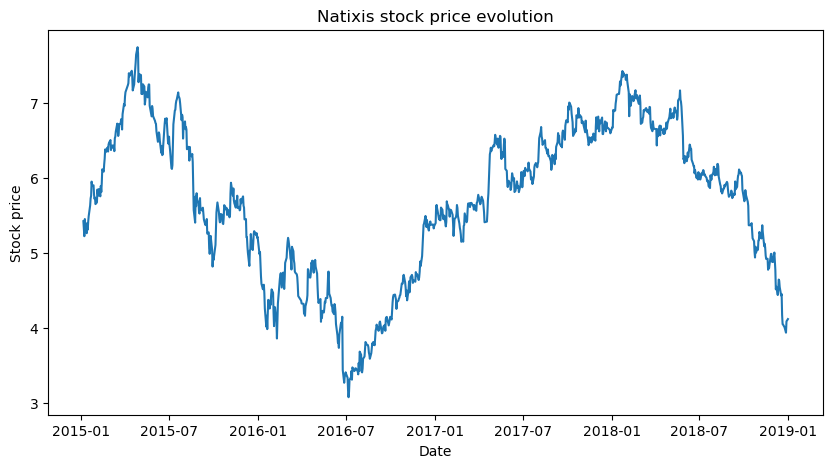

In [8]:
plt.figure(figsize=(10, 5)) # simple visualization of the Natixis stock price over time
plt.plot(data["Date"], data["Value"])
plt.xlabel("Date")
plt.ylabel("Stock price")
plt.title("Natixis stock price evolution")
plt.show()

The asset price moves up and down in a typical way, which is why risk needs to be measured.

#### II. Historical VaR estimation (Question A.a)

We now estimate the historical Value at Risk using a non-parametric approach based on kernel density estimation, as introduced during the lectures.

In [9]:
# on our sorted dataset we select the time periods required to estimate and validate the historical VaR.
data_date_sort_2015 = data[(data["Date"] >= '2015-01-01') & (data["Date"] <= '2016-12-31')]
data_date_sort_2017 = data[(data["Date"] >= '2017-01-01') & (data["Date"] <= '2018-12-31')]

#Once the selection is done now we can sort returns !
data_date_sort_2015 = data_date_sort_2015.sort_values("Returns") # using build in sort function of pandas
data_date_sort_2017 = data_date_sort_2017.sort_values("Returns")

print(data_date_sort_2015) # quick check up

          Date  Value   Returns
378 2016-06-24  3.439 -0.171325
345 2016-05-10  4.083 -0.069083
358 2016-05-27  4.460 -0.061448
405 2016-08-02  3.422 -0.060664
277 2016-02-02  4.208 -0.058613
..         ...    ...       ...
283 2016-02-10  4.101  0.062435
305 2016-03-11  5.083  0.063389
164 2015-08-25  5.755  0.064755
403 2016-07-29  3.685  0.075912
326 2016-04-13  4.785  0.078431

[512 rows x 3 columns]


<span style="color:#1f4fd8"> We recall the definition of the historical Value at Risk as introduced during the lectures (see slide on Value at Risk, page 68). </span>

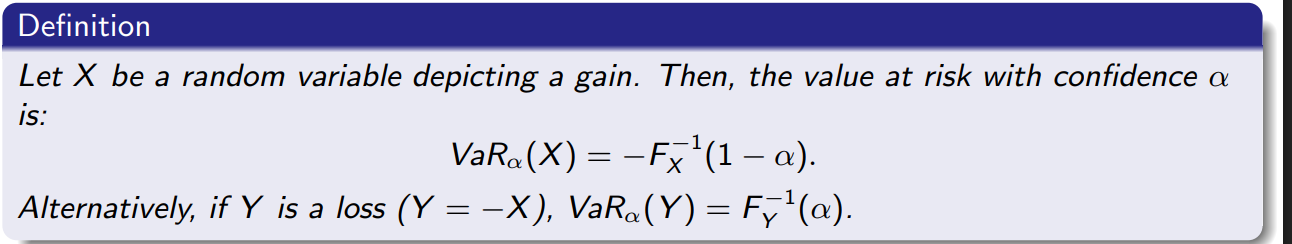

<span style="color:#7a3e0b"><strong>Remark:</strong> We estimate the VaR as the empirical α quantile of the return distribution(definition in the lectures)</span>

In [10]:
# Historical VaR estimation using the empirical quantile
var_historical = np.quantile(data_date_sort_2015["Returns"], alpha)

var_historical_value = - var_historical * value_portfolio # we have VaR expressed in monetary value
var_historical, var_historical_value

(np.float64(-0.03777913198405718), np.float64(3777.9131984057176))

This value corresponds to the maximum expected day loss at the 5% confidence level based on historical returns observed between 2015 and 2016.

We now refine the estimation by using a kernel based non-parametric approach, as required in the project instructions

We use a biweight kernel to estimate the return distribution. <span style="color:#1f4fd8"> The kernel density estimation is used to approximate the distribution and extract the corresponding quantile, as introduced during the lectures (see slide on VaR estimation, page 69). </span>

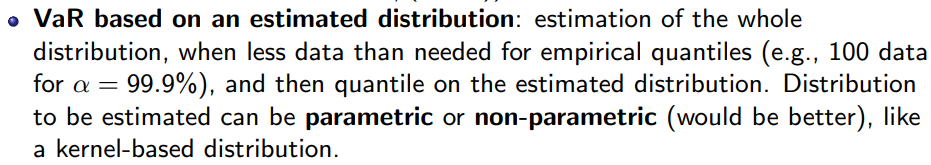

<span style="color:#7a3e0b"><strong>Remark:</strong> The biweight kernel used in the following estimation is directly specified in the project statement.</span>


In [11]:
def kernel(u): # we define the biweight kernel used in the non-parametric estimation
    if abs(u) <= 1:
        return (15/16) * (1 - u**2)**2
    else:
        return 0

def kernel_density(data, x): # Kernel density estimation function where x is the point where the density is evaluated
    # bandwidth chosen 
    h = ((4 * data['Returns'].std()) / (3 * len(data['Returns'])))**0.2
    n = len(data['Returns'])
    kernel_sum = 0

    # we sum the contribution of each observation to the kernel density
    for r in data['Returns']:
        kernel_sum += kernel((x - r) / h)
    return kernel_sum / (n * h)     # final kernel density value

def VaR_Kernel(data, alpha): # function to compute the non-parametric VaR using the kernel distribution
    probabilities = []
    for r in data['Returns']:
        probabilities.append(kernel_density(data, r))

    total = sum(probabilities)  # normalization to ensure probabilities sum to one
    if total != 0:
        probabilities = [p / total for p in probabilities]
    sorted_returns = sorted(data['Returns'])     # computation of the empirical quantile based on cumulative probabilities
    cumulative_prob = 0
    
    for i, p in enumerate(probabilities):
        cumulative_prob += p
        if cumulative_prob >= alpha:
            return sorted_returns[i]

Value_at_Risk = VaR_Kernel(data_date_sort_2015, 0.05)
print(f"Value at Risk of Kernel : {Value_at_Risk}")


Value at Risk of Kernel : -0.03478608556577359


Bonus: We display the kernel density estimate together with the return distribution and the estimated VaR.

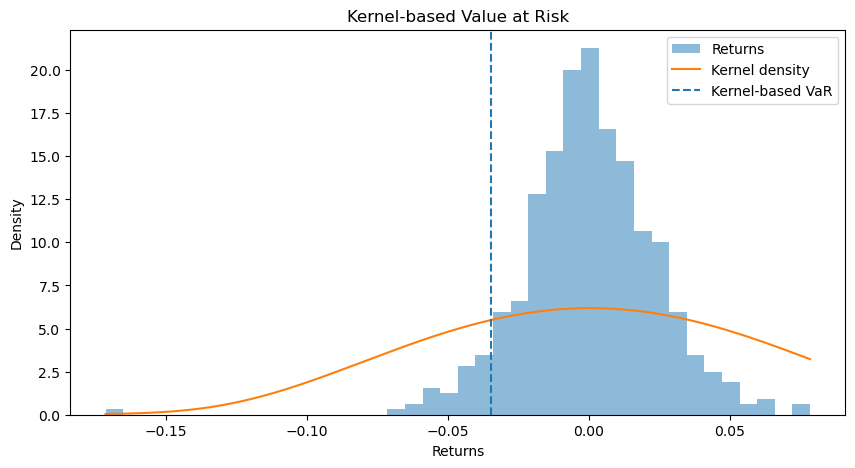

In [12]:
plt.figure(figsize=(10, 5)) # we only use this plot to better understand the results obtained above

plt.hist(data_date_sort_2015["Returns"], bins=40, density=True, alpha=0.5, label="Returns")

x_values = np.linspace(
    data_date_sort_2015["Returns"].min(),
    data_date_sort_2015["Returns"].max(),
    500
)

kernel_values = [kernel_density(data_date_sort_2015, x) for x in x_values] # Kernel density evaluated on the grid

plt.plot(x_values, kernel_values, label="Kernel density")
# vertical line corresponding to the estimated VaR
plt.axvline(Value_at_Risk, linestyle="--", label="Kernel-based VaR")

plt.xlabel("Returns")
plt.ylabel("Density")
plt.title("Kernel-based Value at Risk")
plt.legend()
plt.show()


<span style="color:#0b7a3e"> From the graph, we can see that the estimated VaR is in the left tail of the return distribution and remains very close to the empirical VaR computed previously which confirms the consistency of the historical risk estimation. </span>

#### III. Out-of-sample validation (2017–2018) (Question A.b)

We now evaluate the proportion of returns exceeding the VaR threshold on the 2017–2018 period to assess whether the non-parametric VaR estimated on 2015–2016 data remains relevant

In [13]:
# We now look at how many returns exceed the VaR threshold on the 2017–2018 period

data_2017_2018 = data[
    (data['Date'] >= '2017-01-01') &
    (data['Date'] <= '2018-12-31') # out-of-sample period (2017–2018)
]
returns_2017_2018 = data_2017_2018['Returns']

exceedances = 0

for r in returns_2017_2018:
    if r < Value_at_Risk:
        exceedances += 1 #  count how many times returns fall below the estimated VaR
exceedance_ratio = exceedances / len(returns_2017_2018) #  proportion of exceedances

print("With non-parametric VaR")
print(exceedances, "returns out of", len(returns_2017_2018), "exceed the VaR threshold   ")
print("This corresponds to", round(exceedance_ratio * 100, 2), "% for a risk level of 5%")

With non-parametric VaR
9 returns out of 510 exceed the VaR threshold   
This corresponds to 1.76 % for a risk level of 5%


<span style="color:#0b7a3e"> We observe that the proportion of returns exceeding the VaR threshold (1,76%) is below the nominal confidence level of 5%, which suggests that the non-parametric VaR remains valid on the 2017–2018 period. </span>

<span style="color:#7a3e0b"><strong>Remark:</strong> The kernel-based VaR relies on the assumption that past return dynamics remain representative of future periods which may not always hold in practice. </span>

<span style="color:#0b7a3e"> Overall, the results obtained on both periods are consistent and lead to similar conclusions regarding the level of market risk. </span>

---

### Question B (Ex2, Q5 of TD2) - Expected Shortfall

In this question we compute the Expected Shortfall associated with the non-parametric VaR estimated in Question A.

<span style="color:#7a3e0b"><strong>Remark:</strong> We reuse the same return series as in Question A and the same non-parametric VaR threshold </span>

Since the VaR only gives a quantile of the loss distribution, we also compute the Expected Shortfall to measure the average loss conditional on returns falling below the VaR threshold.  
So we simply average the returns that fall below the VaR threshold.


<span style="color:#7a3e0b"><strong>Remark (sign convention):</strong> VaR and ES take negative values since risk measures are expressed in terms of returns.</span>

<span style="color:#1f5faa"><strong>Course reference:</strong> The Expected Shortfall (also AVaR or conditional VaR) is introduced in the lectures as the average loss conditional on returns exceeding the VaR threshold (see slide “Expected shortfall”, page 75).</span>

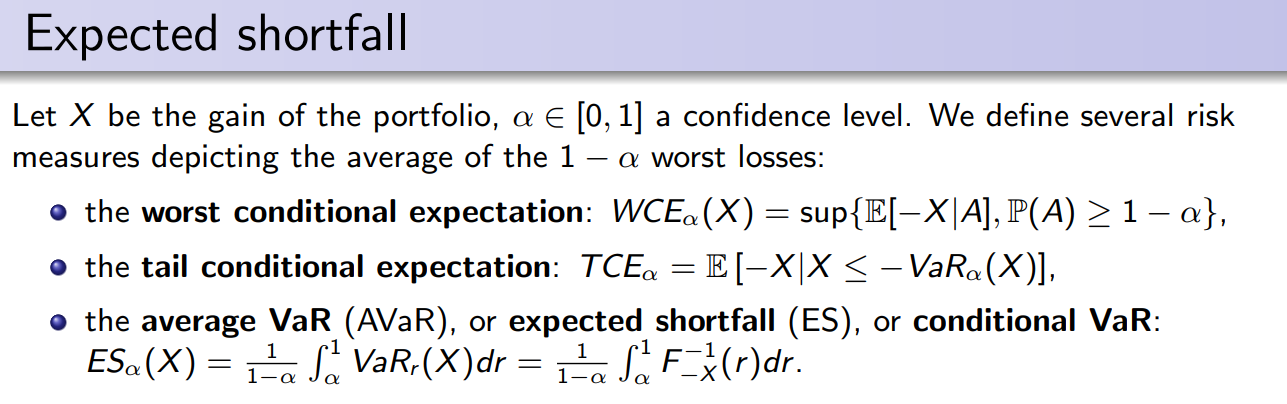

We now compute the Expected Shortfall associated with the non-parametric VaR estimated in Question A.

#### Computation of the Expected Shortfall:

In practice, we simply average the returns that are below the VaR level estimated in Question A.

<span style="color:#7a3e0b"><strong>Remark:</strong> VaR and ES are reported as returns(negative quantities).</span>

In [14]:
#select the returns that are below (or equal to) the VaR threshold
rdt_over_VaR = data_date_sort_2015["Returns"][data_date_sort_2015["Returns"] <= Value_at_Risk]
ES = np.mean(rdt_over_VaR) #mean of that returns

print("Non parametric VaR:", Value_at_Risk)
print("Expected Shortfall (non-parametric):", round(ES, 5))

Non parametric VaR: -0.03478608556577359
Expected Shortfall (non-parametric): -0.05004


<span style="color:#0b7a3e"><strong>Interpretation:</strong> Since risk measures are expressed in terms of returns the Expected Shortfall is more negative than the VaR. This indicates that losses are on average more severe than what the VaR alone suggests.</span>

### Question C (Ex2, Q1 and Q2 of TD3) - Extreme Value Theory (EVT)

In this question, we focus on the analysis of extreme returns using tools from Extreme Value Theory (EVT).  
We rely on the Natixis return series and study separately extreme gains and extreme losses in order to better understand tail behavior.

<span style="color:#7a3e0b"><strong>Remark:</strong> We use the same return series as in Question A but the analysis is towards the extreme tails of the distribution within an EVT framework.</span>

#### I. Data preparation and tail separation (EVT setup, before Question C.a)

To apply Extreme Value Theory, we first split the return distribution into two tails corresponding to extreme gains and extreme losses, which are analyzed separately. Extreme losses are defined as \(L_t = -r_t\) so EVT is applied to the right tail of istribution.

In [15]:
gains = data['Returns'][data['Returns'] > 0]
losses = -data['Returns'][data['Returns'] < 0]# converts losses into positive values, thus EVT applies to the right tail.

gains_sorted = np.sort(gains)
losses_sorted = np.sort(losses) 

#### II. Estimation of GEV parameters using Pickands estimator (Question C.a)

In this part, we estimate the tail index of the return distribution using Extreme Value Theory. We rely on the Pickands estimator to characterize the behavior of extreme gains and extreme losses separately.

<span style="color:#1f5faa"><strong>Course reference:</strong>
We rely on the Pickands estimator introduced in the Extreme Value Theory lectures to estimate the tail index ξ of the return distribution. The following formula defines the estimator used in our implementation (EVT-based VaR estimation slides, page 180).</span> 

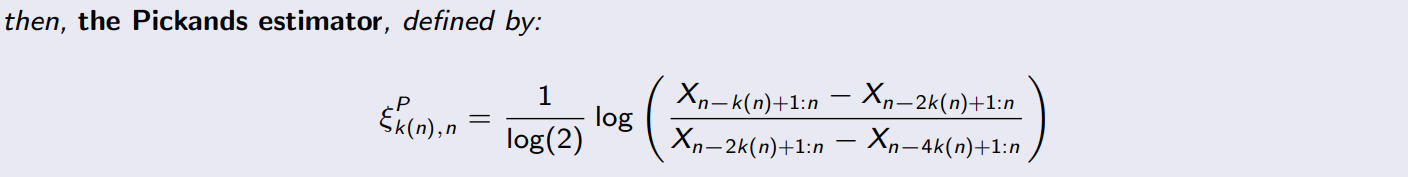

<span style="color:#1f5faa"><strong>Course reference:</strong>
The sign of the tail index ξ allows us to characterize the type of extreme value distribution. ξ > 0 corresponds to a Fréchet distribution (heavy tails), ξ = 0 to a Gumbel distribution, and ξ < 0 to a Weibull distribution. We rely on this classification to interpret our estimates (see EVT lectures, same section, page 166).</span> 

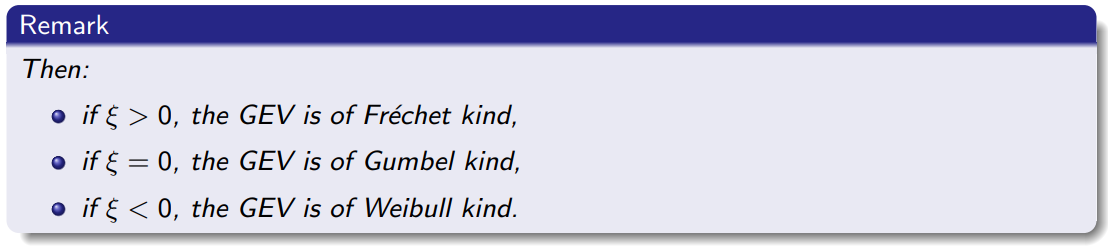

We now apply the Pickands estimator separately to extreme gains and extreme losses.

In [16]:
def pickands_estimator(extreme_values):
 
    #Pickands estimator for the tail index, extreme observations sorted in increasing order.
    n = len(extreme_values)
    
    # We choose the intermediate sequence k(n) = log(n) as suggested in the lectures to find a good balance
    k = int(np.log(n))
    x1 = extreme_values[n - k]  #required order statistics
    x2 = extreme_values[n - 2 * k]
    x3 = extreme_values[n - 4 * k]
    
    # we seek the Pickands estimator according to the theoretical formula
    xi_hat = (1 / np.log(2)) * np.log((x1 - x2) / (x2 - x3))
    return xi_hat

# we estimate the tail index separately for gains and for losses
xi_gains = pickands_estimator(gains_sorted)
xi_losses = pickands_estimator(losses_sorted)
xi_gains, xi_losses

(np.float64(0.5772338569463286), np.float64(-0.508971577934174))

<span style="color:#0b7a3e"><strong>Interpretation:</strong>
We obtain a positive tail index for extreme gains (ξ ≈ 0.58) and a negative tail index for extreme losses (ξ ≈ −0.51) which indicates asymmetry in the tail behavior of Natixis returns. Extreme positive returns exhibit heavy-tailed behavior (Fréchet type distribution) while extreme losses appear to be lighter-tailed (Weibull type distribution_. In practice, this suggests that very large upward movements may occur with more pronounced extremes than downward movements in terms of tail thickness.</span>

<span style="color:#7a3e0b"><strong>Remark:</strong> As in standard EVT applications we suppose returns are independent and identically distributed. Moreover, since the Pickands estimator uses only a limited number of extreme observations, the tail index estimates can be sensitive to sampling variability and to the choice of the intermediate sequence k.</span>

Bonus: As a visual complement, we plot the empirical distributions of extreme gains and extreme losses. This allows us to illustrate the difference in tail behavior highlighted by the Pickands estimates.

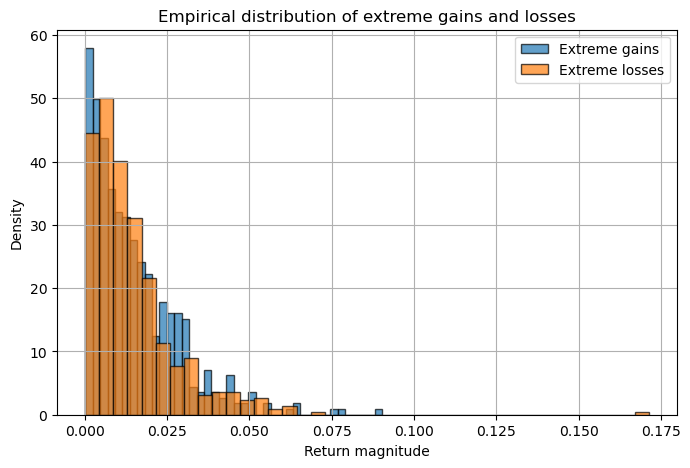

In [17]:
# plot 
plt.figure(figsize=(8, 5))

plt.hist(gains_sorted, bins=40, density=True, alpha=0.7,
         label="Extreme gains", edgecolor="black")

plt.hist(losses_sorted, bins=40, density=True, alpha=0.7,
         label="Extreme losses", edgecolor="black")

plt.xlabel("Return magnitude")
plt.ylabel("Density")
plt.title("Empirical distribution of extreme gains and losses")

plt.legend()
plt.grid(True)
plt.show()

<span style="color:#0b7a3e"><strong>Comment:</strong>
The empirical distributions confirm the asymmetric tail behavior( more pronounced extreme gains than extreme losses)</span>

#### III. EVT  Value at Risk estimation (Question C.b)

In this part, we use Extreme Value Theory to compute Value at Risk estimates based on the tail behavior(characterized before using the Pickands estimator)

We focus on the left tail of the return distribution (losses) since Value at Risk is a downside risk measure. The EVT-based VaR is computed for several confidence levels.

<span style="color:#7a3e0b"><strong>Remark:</strong> The EVT VaR is computed using the tail index estimates obtained in Question C.a. We assume that returns are independent and identically distributed.</span>

<span style="color:#1f5faa"><strong>Course reference:</strong> We use the EVT-based VaR formulation introduced in the lectures where the Value at Risk is expressed using the Pickands estimator of the tail index ξ (see EVT-based VaR estimation slides, page 187).</span>

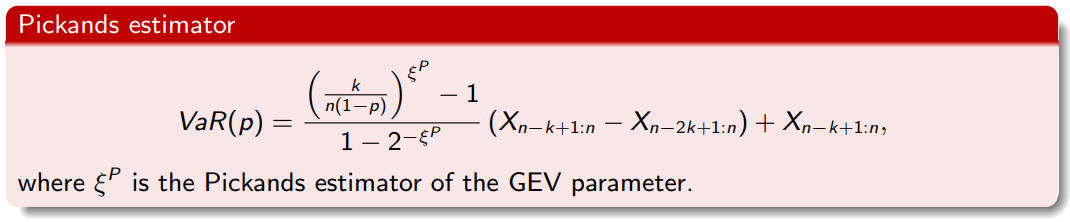

We now compute the EVT Value at Risk for several confidence levels and compare it to the historical VaR obtained in Question A.

<span style="color:#7a3e0b"><strong>Remark:</strong> Like before we work with extreme losses expressed in positive terms. This makes the EVT Value at Risk easier to interpret as a loss threshold and avoids sign mistakes in the implementation.</span>

In [18]:
def var_evt_pickands(extreme_losses, xi_hat, alpha):
   
    n = len(extreme_losses)
    # we keep the same choice of k to ensure consistency between the two steps
    k = int(np.log(n))
    # tail order statistics required by the EVT formula
    x_k = extreme_losses[n - k]
    x_2k = extreme_losses[n - 2 * k]

    numerator = (k / (n * (1 - alpha))) ** xi_hat - 1 #formula
    denominator = 1 - 2 ** (-xi_hat)
    var_evt = (numerator / denominator) * (x_k - x_2k) + x_k
    return var_evt

In [19]:
confidence_levels = [0.90, 0.95, 0.99] #  several confidence levels

for alpha in confidence_levels:
    var_alpha = var_evt_pickands(losses_sorted, abs(xi_losses), alpha)
    print(f"EVT-based VaR (Pickands) at {int(alpha*100)}% confidence level: {var_alpha:.5f}")

EVT-based VaR (Pickands) at 90% confidence level: 0.04570
EVT-based VaR (Pickands) at 95% confidence level: 0.04844
EVT-based VaR (Pickands) at 99% confidence level: 0.06010


<span style="color:#0b7a3e"><strong>Interpretation:</strong> Uwe observe an increasing Value at Risk as the confidence level rises: approximately 4.6% at 90%, 4.8% at 95% and about 6.0% at 99%. This is consistent with the definition of VaR since higher confidence levels focus on more extreme and rarer losses.</span>

<span style="color:#0b7a3e"><strong>Interpretation (methodological note):</strong> 
We recall that EVT-based Value at Risk relies on extrapolation beyond the observed sample using only the tail behavior of the distribution. As a result, the estimates become more sensitive as the confidence level increases</span>


<span style="color:#7a3e0b"><strong>Remark:</strong> Compared to the historical VaR computed in Question A the EVT-based VaR has greater weight on the tail of the loss distribution. As a result, it leads to higher risk estimates at very high confidence levels.
The EVT-based VaR has a limited number of extreme observations and can be sensitive to the choice of the sequence k and to sampling variability.</span>

---

### Question D (Ex2, Q5 of TD4) - Bouchaud Price Impact Model

We now estimate the parameters of Bouchaud’s price impact model using the TD4 framework

<span style="color:#7a3e0b"><strong>Remark:</strong> For this question, we use the dataset provided for TD4 (Dataset_TD4.xlsx), not the Natixis price series used in Questions A-C. The goal is to focus on market impact and liquidity. Thus, the inputs (price, volume, spread, trade direction) are different.</span>

#### I. Data loading and preprocessing (before Question D)

The objective is to obtain a clean, time-indexed table containing the key variables required by the model:
- a price variable 
- traded volume
- bid-ask spread S
- trade sign eps in {-1, +1}

We start by loading the dataset and inspecting its structure.


In [20]:
df_td4 = pd.read_excel("../data/Dataset_TD4.xlsx")
df_td4.head()

,transaction date (1=1day=24 hours),bid-ask spread,volume of the transaction (if known),Sign of the transaction,Price (before transaction)
0,0.000202,0.1100,8.0,-1,100.000
1,0.001070,0.1030,NaN,1,99.984
2,0.001496,0.1015,NaN,-1,100.029
3,0.003336,0.0920,NaN,1,99.979
4,0.003952,0.1106,NaN,1,100.060


We now define the market variables that will be used in Bouchaud’s price impact model.  
We only perform minimal transformations when necessary.

In [21]:

df_vars = df_td4.copy()

df_vars = df_vars.rename(columns={
    "transaction date (1=1day=24 hours)": "time",
    "Price (before transaction)": "price",
    "volume of the transaction (if known)": "volume",
    "bid-ask spread": "spread",
    "Sign of the transaction": "eps" # copy and rename columns without cleaning the dataset
})

df_vars.head()

,time,spread,volume,eps,price
0,0.000202,0.1100,8.0,-1,100.000
1,0.001070,0.1030,NaN,1,99.984
2,0.001496,0.1015,NaN,-1,100.029
3,0.003336,0.0920,NaN,1,99.979
4,0.003952,0.1106,NaN,1,100.060


Bonus: Before moving to the estimation of the price impact model, we briefly look at a few basic plots.  
These visualizations are useful to check the data

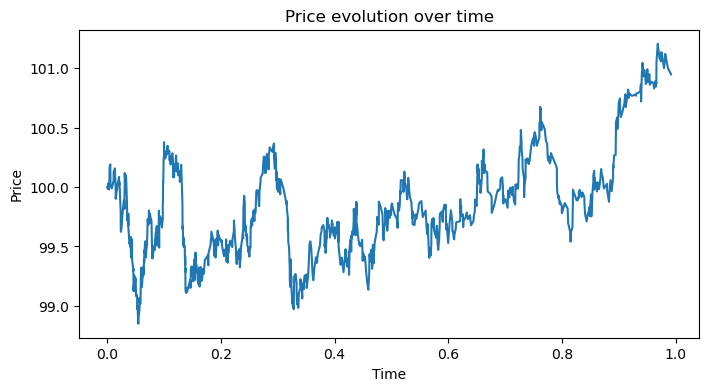

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(df_vars["time"], df_vars["price"])
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Price evolution over time")
plt.show()

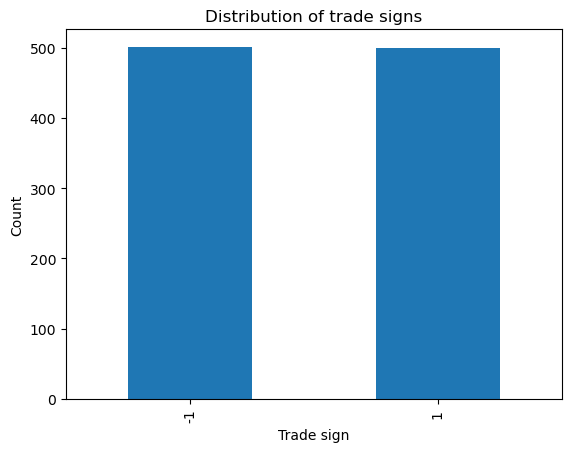

In [23]:
df_vars["eps"].value_counts().plot(kind="bar") # distribution of the trade sign to check balance between buys and sells
plt.title("Distribution of trade signs")
plt.xlabel("Trade sign")
plt.ylabel("Count")
plt.show()

<span style="color:#0b7a3e"><strong>Interpretation:</strong> From these plots, we observe that the distribution of trade signs looks balanced. This is in line with what we would expect before estimating a signed price impact model.</span> 

#### II. Bouchaud price impact model: definition and parameters

We now introduce the price impact model proposed by Bouchaud, which will be used to estimate the impact of trades on prices.

The main idea is that price changes can be written as the cumulative effect of past trades where each trade contributes to the price movement (signed impact that decays over time). This allows us to capture both the direction of trades and the persistence of their impact.

<span style="color:#1f5faa"><strong>Course reference:</strong>In this question, we use the transitory impact model presented in the course, where prices are described as the cumulative effect of past signed trades (see slide page 133 of the lecture notes).</span>  

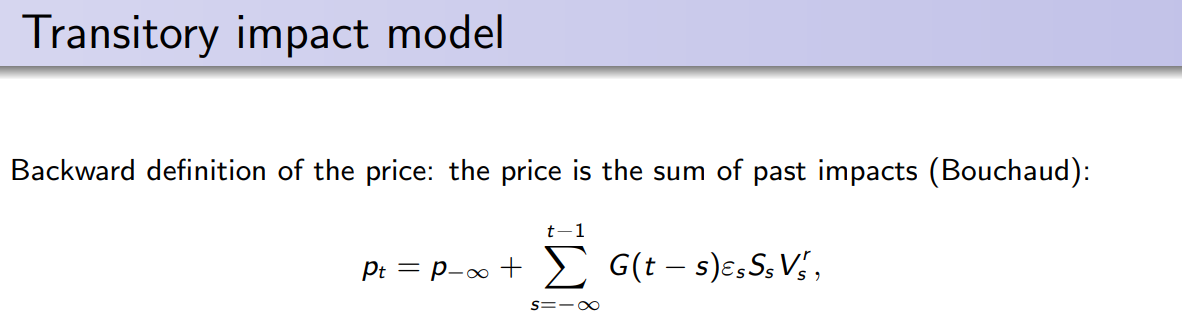

Parameter interpretation: 

The transitory impact model relies on a small number of parameters that jointly determine how trades affect prices both in magnitude and over time.  

- The parameter V is the overall scale of price impact: higher values of V imply that individual trades tend to move prices more strongly.

- The exponent r controls how impact depends on traded volume. When r is smaller than 1, the impact function is concave(commonly observed in empirical studies)

- gamma determines how persistent the impact of past trades is. A larger gamma means a faster decay of impact, while smaller values imply a longer memory in prices.

Finally, the parameter lambda introduced in the TD4 framework is used to control how past information is weighted over time.

#### III. Estimation strategy

We want to recover the parameters that both have an impact on the magnitude and the persistence of price by analising the relationship between price changes and past signed trades. At this stage, we focus on the general estimation logic before turning to the practical implementation.

The underlying idea is that short term price variations can be explained by the cumulative effect of past trades, as predicted by the model. In practice, observed price changes are related to past values through a parametric specification of the impact decay.

The parameters of the model are then estimated by minimizing the deviation between observed price changes and those implied by the model.

<span style="color:#1f5faa"><strong>Course reference:</strong> This estimation approach follows the methodology introduced in TD4, which relies on a parametric specification of the impact kernel and a regression framework.</span>  

##### Implementation details
We first construct the price increments that will be used as the dependent variable in the estimation.

In [24]:
df_est = df_vars.copy()

df_est["delta_price"] = df_est["price"].diff() # we compute price increments from the transaction price

df_est[["time", "price", "delta_price"]].head()

,time,price,delta_price
0,0.000202,100.000,NaN
1,0.001070,99.984,-0.016
2,0.001496,100.029,0.045
3,0.003336,99.979,-0.050
4,0.003952,100.060,0.081


##### Specification of the impact kernel

In order to estimate the model, we need to specify a parametric form for the impact decay function.  
Following the TD4 framework, we assume a power-law decay of impact over time.

<span style="color:#1f5faa"><strong>Course reference:</strong> In TD4, the impact kernel is sdescribed as a decreasing power law function of the lag( captures the gradual decay of price impact over time)</span>  

In [25]:
max_lag = 50
lags = np.arange(1, max_lag + 1) #  lag structure used for the impact kernel

# parametric power law form of the impact kernel
def impact_kernel(lags, gamma):
    return lags ** (-gamma)

##### Parameter estimation

For a given pair (r, gamma), we construct a predictor based on past signed trades and the impact kernel and we estimate the scaling parameter V using ordinary least squares.  
We then explore a simple grid of values for r and gamma and we keep the combination that provides the best fit (mean squared error)

In [26]:
#we only keep trades with known volume here.
df_fit = df_est.copy()
df_fit = df_fit.dropna(subset=["delta_price", "eps", "spread", "volume"]).reset_index(drop=True)

df_fit = df_fit[df_fit["eps"].isin([-1, 1])]
df_fit = df_fit[(df_fit["spread"] >= 0) & (df_fit["volume"] >= 0)]

max_lag = 50 # We keep a reasonable maximum lag for the kernel 
lags = np.arange(1, max_lag + 1)

def impact_kernel_power(lags, gamma):
    # impact decay: G(l) = l^{-gamma}
    return lags ** (-gamma)

def build_regressor(df, r, gamma, max_lag=50):
    """
    We build X_t and we model: delta_price_t ≈ V * X_t
    """
    G = impact_kernel_power(np.arange(1, max_lag + 1), gamma)

    signed_term = df["eps"] * df["spread"] * (df["volume"] ** r)
    X = np.zeros(len(df), dtype=float)
    for l in range(1, max_lag + 1):
        X += G[l - 1] * signed_term.shift(l).fillna(0.0).to_numpy()

    Y = df["delta_price"].to_numpy()
    return X, Y

def estimate_V_ols(X, Y):
    #  OLS 
    denom = np.dot(X, X)
    if denom == 0:
        return np.nan
    return np.dot(X, Y) / denom

def mse(Y, Y_hat):
    return np.mean((Y - Y_hat) ** 2)
# grid search
r_grid = np.arange(0.0, 1.01, 0.1) # concavity exponent
gamma_grid = np.arange(0.1, 2.01, 0.1) # decay exponent

best = {"mse": np.inf, "V": None, "r": None, "gamma": None} # structure using the best result

for r in r_grid:
    for gamma in gamma_grid:
        X, Y = build_regressor(df_fit, r=r, gamma=gamma, max_lag=max_lag)
        valid = np.isfinite(X) & np.isfinite(Y)
        Xv, Yv = X[valid], Y[valid] # build regression variables

        V_hat = estimate_V_ols(Xv, Yv) # estimate parameters
        if np.isnan(V_hat):
            continue
        Y_hat = V_hat * Xv
        current_mse = mse(Yv, Y_hat)

        if current_mse < best["mse"]: # jeep the best parameters
            best = {"mse": current_mse, "V": V_hat, "r": r, "gamma": gamma}

best


{'mse': np.float64(0.005377107972098853),
 'V': np.float64(0.001992121301477238),
 'r': np.float64(0.7000000000000001),
 'gamma': np.float64(2.0)}

In [27]:
pd.DataFrame([best])

,mse,V,r,gamma
0,0.005377,0.001992,0.7,2.0


<span style="color:#0b7a3e"><strong>Interpretation:</strong> The estimated  r is below one meaning a concave dependence of price impact on traded volume. The estimated decay exponent γ is very high implying that trade impact fades quickly and is mostly temporary.

This outcome may reflect a liquid market environment but it may also highlight limitations of the parametric specification or of the chosen lag window.</span>

<strong>Conclusion:</strong>  Using a simple parametric specification of Bouchaud’s transitory impact model we obtain estimates for the concavity and decay of price impact. The results confirm a concave dependence on traded volume and a transitory impact of trades .  
While the model captures key  features of market impact, the boundary estimate for the decay parameter highlights potential limitations of the specification. 


### Question E (Ex2, Q2 and Q3 of TD5) - Multiresolution Correlation & Hurst Exponent

In this question, we study the dependence structure of high frequency FX rates using multiresolution techniques.

First, we analyze the correlation between diferent time scales using Haar wavelets with a particular focus on the Epps effect.
Then we estimate the Hurst exponent of each FX rate in order to study their scaling properties and annualized volatility measures.

<span style="color:#7a3e0b"><strong>Remark:</strong> For this question we do not use the same dataset as in the previous questions.
We work with a new dataset provided in TD5 "Dataset_TD5", which contains a high-frequency FX prices.
a specific preprocessing is required before addressing the question.</span>

#### I. Data Description and Preprocessing (Before answering Question E)

The dataset contains high-frequency foreign exchange rates for three currency pairs:
GBPEUR, SEKEUR and CADEUR.

For each asset, the highest and the lowest prices are available at each time step.
It is necessary to work at the smallest available time resolution because the analysis focuses on correlation and scaling effects.

In [28]:
df_td5 = pd.read_excel("../data/Dataset_TD5.xlsx", header=None)
df_td5.head(10)

,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GBPEUR Curncy,NaN,NaN,NaN,SEKEUR Curncy,NaN,NaN,NaN,CADEUR Curncy,NaN,NaN
2,Date,HIGH,LOW,NaN,Date,HIGH,LOW,NaN,Date,HIGH,LOW
3,2016-03-07 08:59:59.990000,1.2932,1.2917,NaN,2016-03-07 08:59:59.990000,0.10725,0.1072,NaN,2016-03-07 08:59:59.990000,0.6842,0.6829
4,2016-03-07 09:15:00,1.294,1.293,NaN,2016-03-07 09:15:00,0.10728,0.10717,NaN,2016-03-07 09:15:00,0.6849,0.6841
5,2016-03-07 09:30:00,1.2943,1.2922,NaN,2016-03-07 09:30:00,0.10726,0.10719,NaN,2016-03-07 09:30:00,0.6844,0.6837
6,2016-03-07 09:45:00,1.293,1.2913,NaN,2016-03-07 09:45:00,0.10728,0.10721,NaN,2016-03-07 09:45:00,0.6844,0.6839
7,2016-03-07 10:00:00,1.2931,1.2921,NaN,2016-03-07 10:00:00,0.10725,0.10719,NaN,2016-03-07 10:00:00,0.684,0.6835
8,2016-03-07 10:15:00,1.2926,1.2921,NaN,2016-03-07 10:15:00,0.10724,0.10718,NaN,2016-03-07 10:15:00,0.6839,0.6836
9,2016-03-07 10:30:00,1.293,1.2906,NaN,2016-03-07 10:30:00,0.10722,0.1072,NaN,2016-03-07 10:30:00,0.684,0.6834


From the raw output above, we can see that the dataset is not stored in a flat tabular format. Instead it's rather organized into separate blocks for each currency pair with several unnamed or empty columns.
As a result, we will first clean and reorganize the data in order to extract consistent time series before constructing prices and returns.

In [35]:
df_clean = df_td5.iloc[3:, [0, 1, 2, 4, 5, 6, 8, 9, 10]] # we remove the first 3 rows of the dataset

df_clean.columns = [
    "Date_GBPEUR", "High_GBPEUR", "Low_GBPEUR",
    "Date_SEKEUR", "High_SEKEUR", "Low_SEKEUR",
    "Date_CADEUR", "High_CADEUR", "Low_CADEUR"
]
    
df_clean["Date_GBPEUR"] = pd.to_datetime(df_clean["Date_GBPEUR"]) # we rename the column and convert datetime format.
df_clean["Date_SEKEUR"] = pd.to_datetime(df_clean["Date_SEKEUR"])
df_clean["Date_CADEUR"] = pd.to_datetime(df_clean["Date_CADEUR"])

df_clean.shape
df_clean.head()

,Date_GBPEUR,High_GBPEUR,Low_GBPEUR,Date_SEKEUR,High_SEKEUR,Low_SEKEUR,Date_CADEUR,High_CADEUR,Low_CADEUR
3,2016-03-07 08:59:59.990,1.2932,1.2917,2016-03-07 08:59:59.990,0.10725,0.1072,2016-03-07 08:59:59.990,0.6842,0.6829
4,2016-03-07 09:15:00.000,1.294,1.293,2016-03-07 09:15:00.000,0.10728,0.10717,2016-03-07 09:15:00.000,0.6849,0.6841
5,2016-03-07 09:30:00.000,1.2943,1.2922,2016-03-07 09:30:00.000,0.10726,0.10719,2016-03-07 09:30:00.000,0.6844,0.6837
6,2016-03-07 09:45:00.000,1.293,1.2913,2016-03-07 09:45:00.000,0.10728,0.10721,2016-03-07 09:45:00.000,0.6844,0.6839
7,2016-03-07 10:00:00.000,1.2931,1.2921,2016-03-07 10:00:00.000,0.10725,0.10719,2016-03-07 10:00:00.000,0.684,0.6835


After reorganizing the dataset, we now construct a representative price series for each FX rate and compute the corresponding returns, which will be used in the subsequent analysis.

In [36]:
df_clean["Avg_GBPEUR"] = (df_clean["High_GBPEUR"] + df_clean["Low_GBPEUR"]) / 2
df_clean["Avg_SEKEUR"] = (df_clean["High_SEKEUR"] + df_clean["Low_SEKEUR"]) / 2 # we work with average prices to reduce microstructure noise
df_clean["Avg_CADEUR"] = (df_clean["High_CADEUR"] + df_clean["Low_CADEUR"]) / 2

df_clean[["Avg_GBPEUR", "Avg_SEKEUR", "Avg_CADEUR"]] = \
    df_clean[["Avg_GBPEUR", "Avg_SEKEUR", "Avg_CADEUR"]].astype(float)

df_clean["Ret_GBPEUR"] = df_clean["Avg_GBPEUR"].pct_change() # we compute returns from average prices
df_clean["Ret_SEKEUR"] = df_clean["Avg_SEKEUR"].pct_change()
df_clean["Ret_CADEUR"] = df_clean["Avg_CADEUR"].pct_change()

df_clean = df_clean.dropna()